In [ ]:
import shap 
import pandas as pd  
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from scipy.stats import spearmanr

C:\Users\agamv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
list(df)
df = df.drop(columns=['Project', 'Case_ID', 'Primary_Diagnosis'])
df = df[~df['Gender'].isin(['--', 'not reported'])]
df = df[~df['Age_at_diagnosis'].isin(['--', 'not reported'])]
df = df[~df['Race'].isin(['--', 'not reported'])]

In [3]:
def parse_age(age_str):
    parts = age_str.split()
    years = int(parts[0])
    days = int(parts[2]) if len(parts) >= 4 else 0
    return round(years + days / 365.25, 2)

In [4]:
df['Age_at_diagnosis'] = df['Age_at_diagnosis'].apply(parse_age)
mutation_cols = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16',
                 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1',
                 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']
for col in mutation_cols:
    df[col] = df[col].map({'MUTATED': 1, 'NOT_MUTATED': 0})
df['Grade'] = df['Grade'].map({'LGG': 0, 'GBM': 1})

print(df.shape)              
print(df['Grade'].value_counts())
print(df.dtypes)
print(df.isnull().sum())

(839, 24)
Grade
0    487
1    352
Name: count, dtype: int64
Grade                 int64
Gender               object
Age_at_diagnosis    float64
Race                 object
IDH1                  int64
TP53                  int64
ATRX                  int64
PTEN                  int64
EGFR                  int64
CIC                   int64
MUC16                 int64
PIK3CA                int64
NF1                   int64
PIK3R1                int64
FUBP1                 int64
RB1                   int64
NOTCH1                int64
BCOR                  int64
CSMD3                 int64
SMARCA4               int64
GRIN2A                int64
IDH2                  int64
FAT4                  int64
PDGFRA                int64
dtype: object
Grade               0
Gender              0
Age_at_diagnosis    0
Race                0
IDH1                0
TP53                0
ATRX                0
PTEN                0
EGFR                0
CIC                 0
MUC16               0
PIK3CA      

In [5]:
X = df.drop(columns=['Grade', 'Gender', 'Race'])
Y = df.Grade

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=25)
clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")
explainer_lr = shap.KernelExplainer(clf.predict_proba, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)

Using 671 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Logistic Regression model accuracy: 88.10%


100%|██████████| 168/168 [01:09<00:00,  2.40it/s]


In [6]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, Y, test_size=0.2, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train2, y_train2)
y_pred = classifier.predict(X_test2)
accuracy = accuracy_score(y_test2, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
conf_matrix = confusion_matrix(y_test2, y_pred)
background = shap.kmeans(X_train2, 50)
explainer_rf = shap.KernelExplainer(classifier.predict_proba, background)
shap_values_rf = explainer_rf.shap_values(X_test2)


Accuracy: 80.95%


100%|██████████| 168/168 [01:51<00:00,  1.51it/s]


In [7]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, Y, test_size=0.2, random_state=42)
params = {
    'objective': 'binary:logistic',
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'alpha': 10
}
model = XGBClassifier(**params)
model.fit(X_train3, y_train3)
y_pred3 = model.predict(X_test3)
accuracy = accuracy_score(y_test3, y_pred3)
print("Model Accuracy:", accuracy)
print("\nClassification Report")
print(classification_report(y_test3, y_pred3))
background = shap.kmeans(X_train3, 50)
explainer_xgb = shap.KernelExplainer(lambda x: model.predict_proba(x), background)
shap_values_xgb = explainer_xgb.shap_values(X_test3)

Model Accuracy: 0.8690476190476191

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        89
           1       0.82      0.92      0.87        79

    accuracy                           0.87       168
   macro avg       0.87      0.87      0.87       168
weighted avg       0.88      0.87      0.87       168



100%|██████████| 168/168 [00:08<00:00, 20.19it/s]


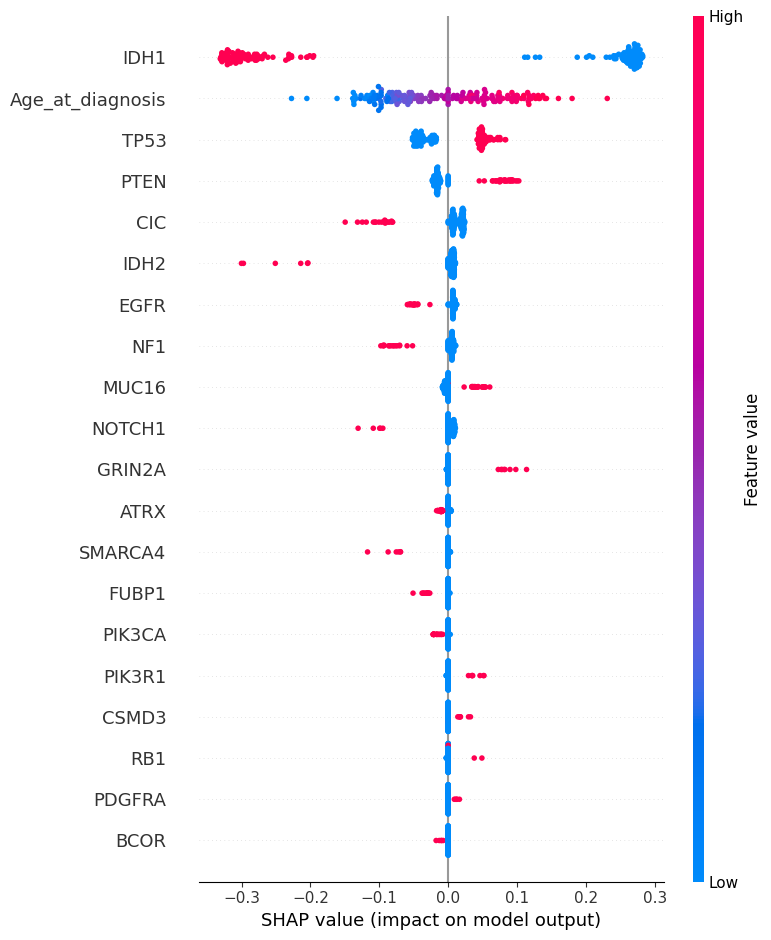

In [8]:
shap.summary_plot(shap_values_lr[:, :, 1], X_test, show=False)

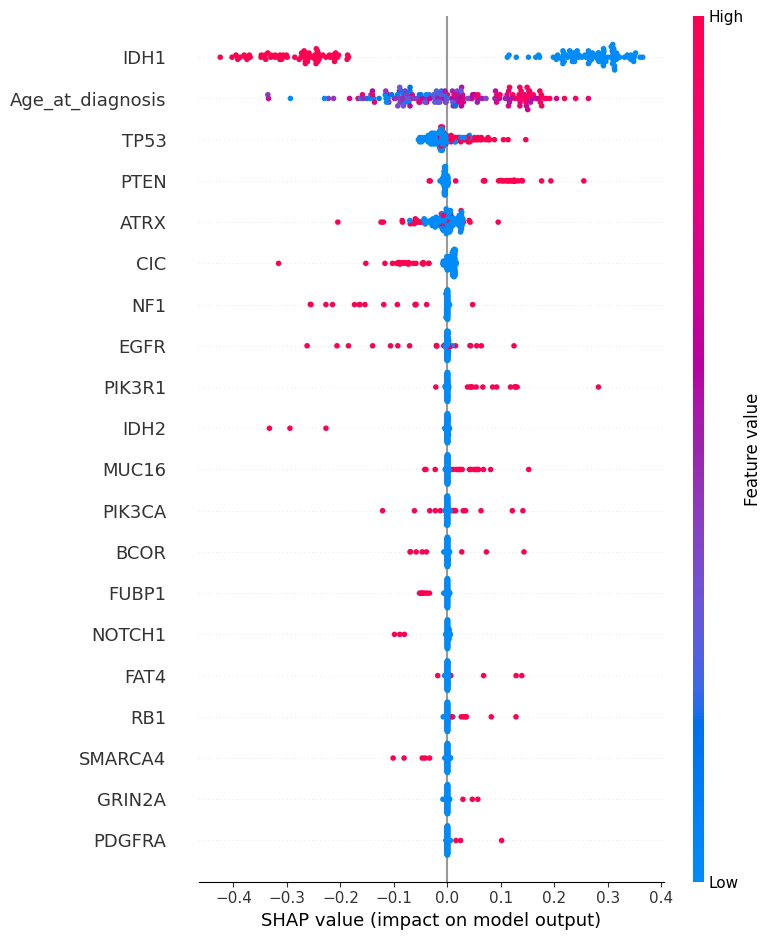

In [9]:
shap.summary_plot(shap_values_rf[:, :, 1], X_test2, show=False)


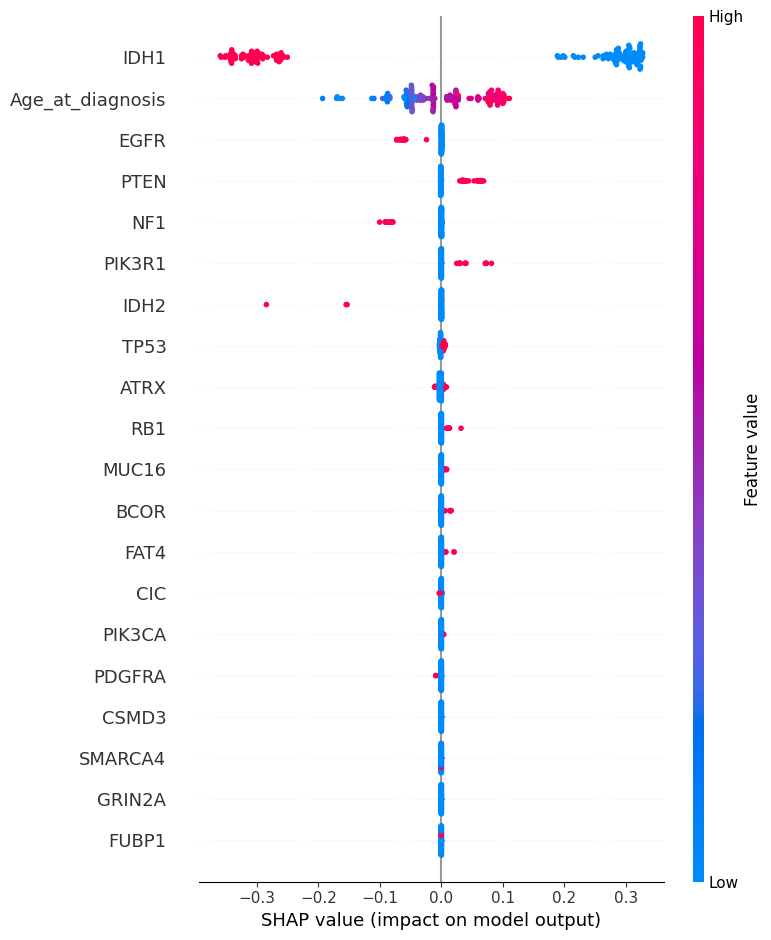

In [10]:
shap.summary_plot(shap_values_xgb[:, :, 1], X_test3, show=False)

In [11]:
weight_vector = {
    "IDH1": 1.0,   # Mandatory diagnostic
    "IDH2": 1.0,   # Mandatory diagnostic
    "ATRX": 0.75,  # Strongly recommended — LGG subtype classification
    "TP53": 0.75,  # Strongly recommended — LGG subtype classification
    "EGFR": 0.5,   # Supportive — GBM pathogenesis
    "PTEN": 0.5,   # Supportive — GBM pathogenesis
    "NF1":  0.5,   # Supportive — GBM pathogenesis
    "CIC":      0.25,  # Incidental
    "MUC16":    0.25,  # Incidental
    "PIK3CA":   0.25,  # Incidental
    "PIK3R1":   0.25,  # Incidental
    "FUBP1":    0.25,  # Incidental
    "RB1":      0.25,  # Incidental
    "NOTCH1":   0.25,  # Incidental
    "BCOR":     0.25,  # Incidental
    "CSMD3":    0.25,  # Incidental
    "SMARCA4":  0.25,  # Incidental
    "GRIN2A":   0.25,  # Incidental
    "FAT4":     0.25,  # Incidental
    "PDGFRA":   0.25,  # Incidental
    "Age_at_diagnosis": 0.6,  # Established prognostic factor (EORTC nomogram)
}

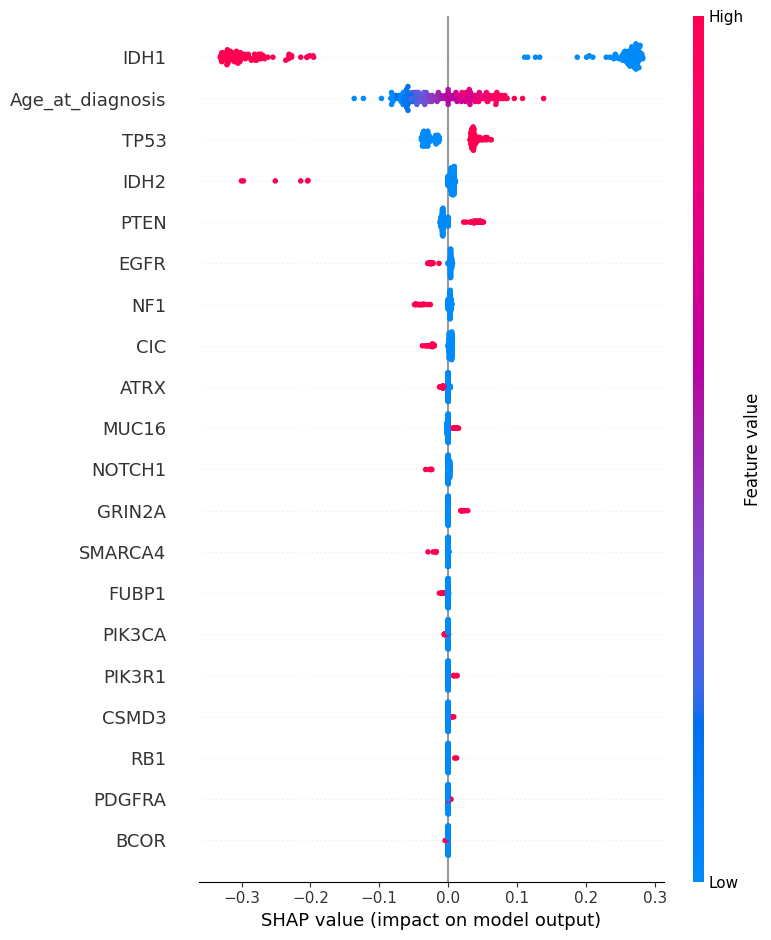

In [12]:
weight_array = np.array([weight_vector[col] for col in X.columns])

weighted_shap_lr  = shap_values_lr[:, :, 1]  * weight_array
weighted_shap_rf  = shap_values_rf[:, :, 1]  * weight_array
weighted_shap_xgb = shap_values_xgb[:, :, 1] * weight_array

shap.summary_plot(weighted_shap_lr,  X_test,  show=False)


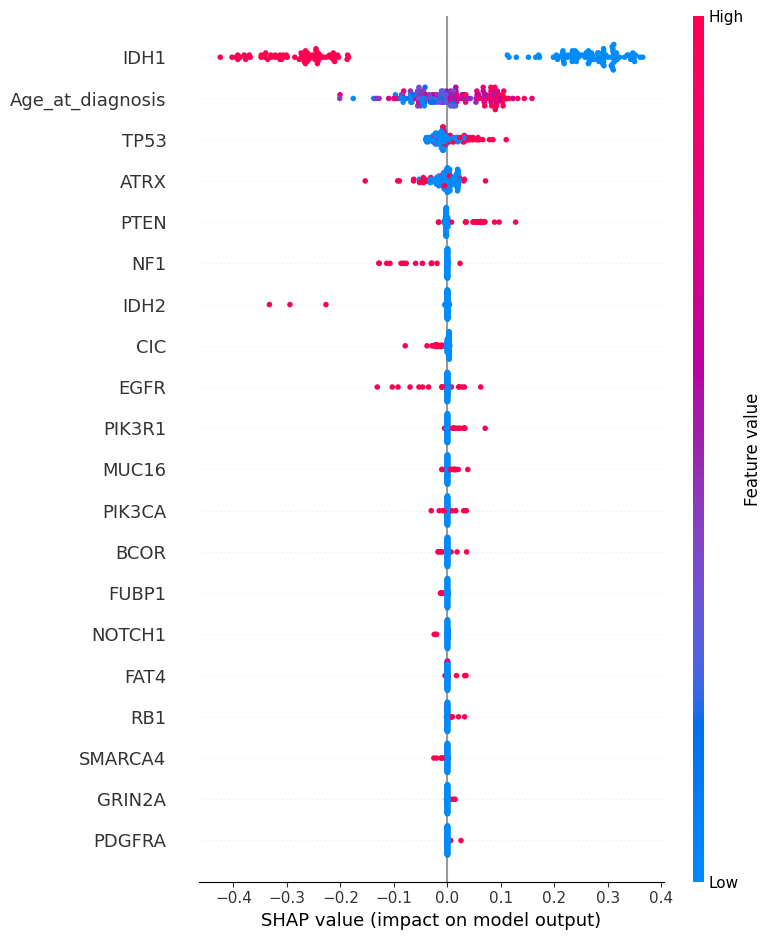

In [ ]:
shap.summary_plot(weighted_shap_rf,  X_test2, show=False)

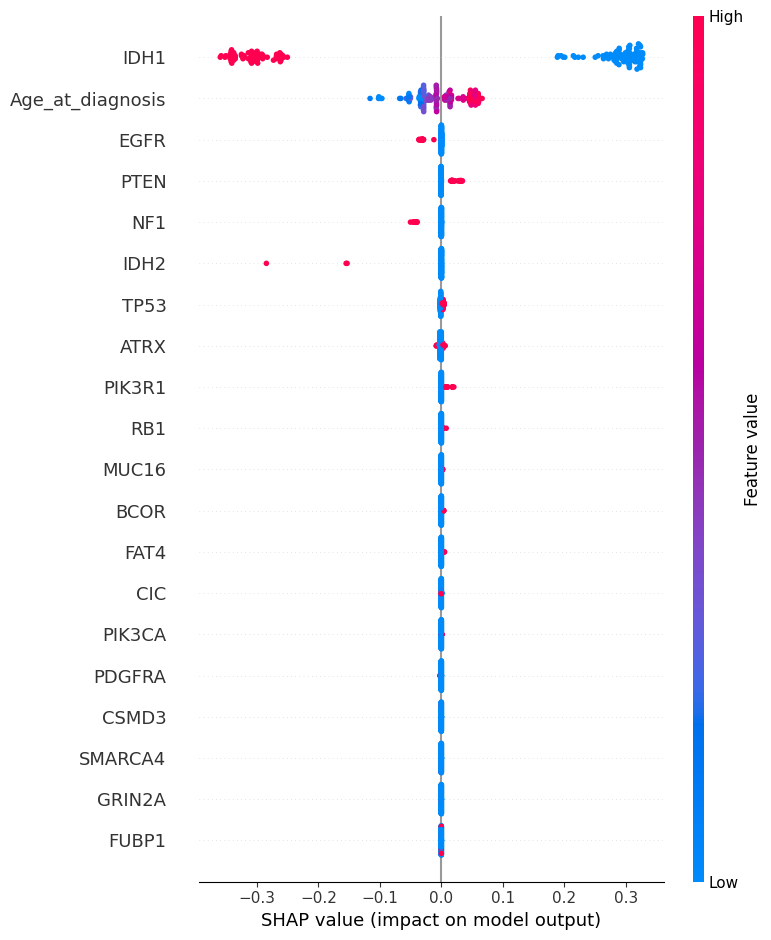

In [14]:
shap.summary_plot(weighted_shap_xgb, X_test3, show=False)

In [15]:
weighted_importance_lr  = np.abs(weighted_shap_lr).mean(axis=0)
weighted_importance_rf  = np.abs(weighted_shap_rf).mean(axis=0)
weighted_importance_xgb = np.abs(weighted_shap_xgb).mean(axis=0)

In [16]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight':  weight_array,
    'LR':      weighted_importance_lr,
    'RF':      weighted_importance_rf,
    'XGB':     weighted_importance_xgb
}).sort_values('LR', ascending=False)
print(importance_df)

             Feature  Weight        LR        RF       XGB
1               IDH1    1.00  0.272782  0.275365  0.299065
0   Age_at_diagnosis    0.60  0.045279  0.057227  0.034622
2               TP53    0.75  0.033208  0.019013  0.001688
18              IDH2    1.00  0.014270  0.005432  0.003630
4               PTEN    0.50  0.013766  0.011421  0.004357
5               EGFR    0.50  0.006489  0.004752  0.004436
9                NF1    0.50  0.006242  0.006339  0.003832
6                CIC    0.25  0.006150  0.005064  0.000057
3               ATRX    0.75  0.002810  0.016617  0.001556
7              MUC16    0.25  0.001996  0.001314  0.000146
13            NOTCH1    0.25  0.001769  0.000614  0.000002
17            GRIN2A    0.25  0.001059  0.000268  0.000004
16           SMARCA4    0.25  0.000756  0.000519  0.000006
11             FUBP1    0.25  0.000560  0.000622  0.000004
8             PIK3CA    0.25  0.000504  0.001107  0.000054
10            PIK3R1    0.25  0.000453  0.001976  0.0009

In [17]:
raw_importance_lr  = np.abs(shap_values_lr[:, :, 1]).mean(axis=0)
raw_importance_rf  = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
raw_importance_xgb = np.abs(shap_values_xgb[:, :, 1]).mean(axis=0)

In [18]:
corr_lr,  p_lr  = spearmanr(importance_df['Weight'], importance_df['LR'])
corr_rf,  p_rf  = spearmanr(importance_df['Weight'], importance_df['RF'])
corr_xgb, p_xgb = spearmanr(importance_df['Weight'], importance_df['XGB'])

In [19]:
print("\n=== Weighted SHAP Spearman (sanity check — confirms correct implementation) ===")
print(f"LR  — ρ: {corr_lr:.4f},  p: {p_lr:.4f}")
print(f"RF  — ρ: {corr_rf:.4f},  p: {p_rf:.4f}")
print(f"XGB — ρ: {corr_xgb:.4f}, p: {p_xgb:.4f}")


=== Weighted SHAP Spearman (sanity check — confirms correct implementation) ===
LR  — ρ: 0.8262,  p: 0.0000
RF  — ρ: 0.8277,  p: 0.0000
XGB — ρ: 0.8061, p: 0.0000


In [20]:
corr_raw_lr,  p_raw_lr  = spearmanr(weight_array, raw_importance_lr)
corr_raw_rf,  p_raw_rf  = spearmanr(weight_array, raw_importance_rf)
corr_raw_xgb, p_raw_xgb = spearmanr(weight_array, raw_importance_xgb)

print("\n=== Raw SHAP Spearman (primary validation — model vs clinical weights) ===")
print(f"LR  — ρ: {corr_raw_lr:.4f},  p: {p_raw_lr:.4f}")
print(f"RF  — ρ: {corr_raw_rf:.4f},  p: {p_raw_rf:.4f}")
print(f"XGB — ρ: {corr_raw_xgb:.4f}, p: {p_raw_xgb:.4f}")


=== Raw SHAP Spearman (primary validation — model vs clinical weights) ===
LR  — ρ: 0.7226,  p: 0.0002
RF  — ρ: 0.7621,  p: 0.0001
XGB — ρ: 0.7517, p: 0.0001


In [21]:
rank_df = pd.DataFrame({
    'Feature':      list(X.columns),
    'Weight':       weight_array,
    'Raw_Rank_LR':  pd.Series(raw_importance_lr).rank(ascending=False).astype(int).values,
    'Wtd_Rank_LR':  pd.Series(weighted_importance_lr).rank(ascending=False).astype(int).values,
    'Raw_Rank_RF':  pd.Series(raw_importance_rf).rank(ascending=False).astype(int).values,
    'Wtd_Rank_RF':  pd.Series(weighted_importance_rf).rank(ascending=False).astype(int).values,
    'Raw_Rank_XGB': pd.Series(raw_importance_xgb).rank(ascending=False).astype(int).values,
    'Wtd_Rank_XGB': pd.Series(weighted_importance_xgb).rank(ascending=False).astype(int).values,
})


In [22]:
rank_df['Shift_LR']  = rank_df['Raw_Rank_LR']  - rank_df['Wtd_Rank_LR']
rank_df['Shift_RF']  = rank_df['Raw_Rank_RF']  - rank_df['Wtd_Rank_RF']
rank_df['Shift_XGB'] = rank_df['Raw_Rank_XGB'] - rank_df['Wtd_Rank_XGB']

print("\n=== Rank Shift Analysis (positive = promoted, negative = demoted) ===")
print(rank_df[['Feature', 'Weight',
               'Raw_Rank_LR',  'Wtd_Rank_LR',  'Shift_LR',
               'Raw_Rank_RF',  'Wtd_Rank_RF',  'Shift_RF',
               'Raw_Rank_XGB', 'Wtd_Rank_XGB', 'Shift_XGB']]
      .sort_values('Shift_LR', ascending=False)
      .to_string(index=False))


=== Rank Shift Analysis (positive = promoted, negative = demoted) ===
         Feature  Weight  Raw_Rank_LR  Wtd_Rank_LR  Shift_LR  Raw_Rank_RF  Wtd_Rank_RF  Shift_RF  Raw_Rank_XGB  Wtd_Rank_XGB  Shift_XGB
            ATRX    0.75           12            9         3            5            4         1             9             8          1
            IDH2    1.00            6            4         2           10            7         3             7             6          1
            EGFR    0.50            7            6         1            8            9        -1             3             3          0
             NF1    0.50            8            7         1            7            6         1             5             5          0
Age_at_diagnosis    0.60            2            2         0            2            2         0             2             2          0
          PDGFRA    0.25           19           19         0           20           20         0            16   

In [23]:
# Logistic Regression misclassifications
y_pred_lr = clf.predict(X_test)
misclassified_lr = np.where(y_pred_lr != y_test.values)[0]

# Random Forest misclassifications  
misclassified_rf = np.where(y_pred != y_test2.values)[0]

# XGBoost misclassifications
misclassified_xgb = np.where(y_pred3 != y_test3.values)[0]

print(f"LR misclassified: {len(misclassified_lr)}")
print(f"RF misclassified: {len(misclassified_rf)}")
print(f"XGB misclassified: {len(misclassified_xgb)}")

LR misclassified: 20
RF misclassified: 32
XGB misclassified: 22


In [24]:
feature_names = list(X.columns)

def get_top_features(shap_row, feature_names, n=3):
    abs_vals = np.abs(shap_row)
    top_idx = np.argsort(abs_vals)[::-1][:n]
    return [(feature_names[i], round(shap_row[i], 4)) for i in top_idx]

In [25]:
def misclassification_report(model_name, misclassified_idx,
                              raw_shap, weighted_shap,
                              X_test_local, y_test_local, y_pred_local,
                              feature_names, weight_vector):
    records = []
    for i in misclassified_idx:
        true_label  = 'GBM' if y_test_local.values[i] == 1 else 'LGG'
        pred_label  = 'GBM' if y_pred_local[i] == 1 else 'LGG'
        
        raw_top     = get_top_features(raw_shap[i], feature_names)
        wtd_top     = get_top_features(weighted_shap[i], feature_names)
        
        # Clinical quality score: average weight of top-3 features
        raw_score   = np.mean([weight_vector[f] for f, _ in raw_top])
        wtd_score   = np.mean([weight_vector[f] for f, _ in wtd_top])
        
        records.append({
            'Model':        model_name,
            'Sample':       i,
            'True':         true_label,
            'Predicted':    pred_label,
            'Raw_Top3':     ', '.join([f for f, _ in raw_top]),
            'Wtd_Top3':     ', '.join([f for f, _ in wtd_top]),
            'Raw_ClinScore':  round(raw_score, 3),
            'Wtd_ClinScore':  round(wtd_score, 3),
            'Improvement':  round(wtd_score - raw_score, 3)
        })
    return pd.DataFrame(records)

In [26]:
df_lr  = misclassification_report(
    'LR',  misclassified_lr,
    shap_values_lr[:, :, 1],  weighted_shap_lr,
    X_test,  y_test,  y_pred_lr,
    feature_names, weight_vector)

df_rf  = misclassification_report(
    'RF',  misclassified_rf,
    shap_values_rf[:, :, 1],  weighted_shap_rf,
    X_test2, y_test2, y_pred,
    feature_names, weight_vector)

df_xgb = misclassification_report(
    'XGB', misclassified_xgb,
    shap_values_xgb[:, :, 1], weighted_shap_xgb,
    X_test3, y_test3, y_pred3,
    feature_names, weight_vector)

all_cases = pd.concat([df_lr, df_rf, df_xgb], ignore_index=True)
print(all_cases.to_string(index=False))
print(f"\nCases where re-weighting improved clinical score: "
      f"{(all_cases['Improvement'] > 0).sum()} / {len(all_cases)}")

Model  Sample True Predicted                       Raw_Top3                       Wtd_Top3  Raw_ClinScore  Wtd_ClinScore  Improvement
   LR      38  GBM       LGG   IDH1, TP53, Age_at_diagnosis   IDH1, TP53, Age_at_diagnosis          0.783          0.783        0.000
   LR      40  GBM       LGG             IDH1, TP53, PIK3R1   IDH1, TP53, Age_at_diagnosis          0.667          0.783        0.117
   LR      65  LGG       GBM   IDH1, TP53, Age_at_diagnosis   IDH1, TP53, Age_at_diagnosis          0.783          0.783        0.000
   LR      68  LGG       GBM   IDH1, Age_at_diagnosis, EGFR   IDH1, Age_at_diagnosis, TP53          0.700          0.783        0.083
   LR      69  GBM       LGG    IDH1, CIC, Age_at_diagnosis   IDH1, Age_at_diagnosis, TP53          0.617          0.783        0.167
   LR      76  LGG       GBM                IDH1, NF1, TP53                IDH1, NF1, TP53          0.750          0.750        0.000
   LR      94  LGG       GBM   IDH1, Age_at_diagnosis, TP53   

In [27]:
print(f"Mean raw clinical score:     {all_cases['Raw_ClinScore'].mean():.3f}")
print(f"Mean weighted clinical score: {all_cases['Wtd_ClinScore'].mean():.3f}")
print(f"Mean improvement overall:     {all_cases['Improvement'].mean():.3f}")
print(f"\nAmong improved cases only:")
improved = all_cases[all_cases['Improvement'] > 0]
print(f"Mean improvement: {improved['Improvement'].mean():.3f}")
print(f"Max improvement:  {improved['Improvement'].max():.3f}")

Mean raw clinical score:     0.724
Mean weighted clinical score: 0.738
Mean improvement overall:     0.014

Among improved cases only:
Mean improvement: 0.094
Max improvement:  0.167
